# 01 Symbol Backtest - MA Cross

Use this notebook to inspect one symbol/timeframe in detail. The report helpers are research-only and call the MA Cross backtest logic without changing strategy behavior.


In [1]:
# Cell 1 - Safe import path bootstrap

import sys
from pathlib import Path


def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'pyproject.toml').exists() and (p / 'core_python' / 'shared').exists():
            return p
    raise RuntimeError('Cannot find SEN05 repo root')


ROOT = find_root(Path.cwd())
CORE = ROOT / 'core_python'
for p in (str(ROOT), str(CORE)):
    if p not in sys.path:
        sys.path.insert(0, p)

print('ROOT =', ROOT)


ROOT = d:\Auto Trading\SEN05


In [2]:
# Cell 2 - Imports and notebook setup

from IPython.display import display

from core_python.strategies.ma_cross.params import SYMBOLS, TIMEFRAMES
from core_python.strategies.ma_cross.research_utils import (
    build_symbol_backtest_widget,
    build_symbol_replay_backtest_widget,
    configure_notebook,
    export_ctrader_validation_bundle,
    render_symbol_backtest_report,
    run_timeframe_matrix,
    show_note,
    show_run_config,
    show_strategy_summary,
)
from core_python.strategies.ma_cross.symbol.backtest import run_symbol_backtest

configure_notebook()
show_strategy_summary()
print('Symbols:', ', '.join(SYMBOLS.keys()))
print('Timeframes:', ', '.join(TIMEFRAMES))


```text
Strategy      : MA_Cross v1.0
Order type    : market at next_bar_open
Execution     : market_single
MA            : SMA10/20
ATR stop      : 2.0 x ATR14
Partial TP    : 50% at 2.0 x ATR
Trailing      : slow_ma after 1.0 x ATR
Timeframes    : M20, M30, M45
Risk          : 0.50% per trade
Symbols       : US30, US500, US100, DE40, UK100, FR40, SP35, HK50, J225, GOLD, BTCUSD
Default broker: ftmo_2step_mt5
```

Symbols: US30, US500, US100, DE40, UK100, FR40, SP35, HK50, J225, GOLD, BTCUSD
Timeframes: M20, M30, M45


In [ ]:
# Cell 3 - Run configuration

RUN_CONFIG = {
    'symbol': 'US30',
    'account_mode': 'standard',
    'tf': 'M30',
    'initial_balance': 100_000.0,
    'date_from': '2023-01-01',
    'date_to': None,
    'max_bars': 50_000,
    'indicator_overrides': {},
    'strategy_overrides': {},
    'costs': {},
    'broker_profile': None,
    'collect_events': True,
    'export_ctrader': True,
    'replay': {
        'lookback_bars': 80,
        'step_bars': 1,
        'default_speed_ms': 800,
        'show_signals': True,
        'show_entries': True,
        'show_exits': True,
    },
}

show_run_config('MA Cross Symbol Backtest Configuration', RUN_CONFIG)


Parameter,Value
symbol,US30
account_mode,standard
tf,M30
initial_balance,"100,000"
date_from,2023-01-01
date_to,None
max_bars,"50,000"
indicator_overrides,{}
strategy_overrides,{}
costs,{}


In [4]:
# Cell 4 - Interactive symbol backtest dashboard

symbol_dashboard = build_symbol_backtest_widget(
    symbols=SYMBOLS,
    run_symbol_backtest=run_symbol_backtest,
    default_config=RUN_CONFIG,
    global_ns=globals(),
)
display(symbol_dashboard)


d:\Auto Trading\SEN05\core_python\shared\data.py:423: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
[symbol_id=10, tf=M20] BarTime is timezone-naive and source timezone is unknown; assuming UTC.
[symbol_id=10, tf=M20] Phat hien 29 khoang trong thoi gian bat thuong; gap dau tien: 2026-03-24 03:40:00+00:00 -> 2026-03-24 04:20:00+00:00
d:\Auto Trading\SEN05\core_python\shared\data.py:423: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(
[symbol_id=10, tf=M30] BarTime is timezone-naive and source timezone is unknown; assuming UTC.
[symbol_id=10, tf=M30] Phat hien 163 khoang trong thoi gian bat thuong; gap dau tien: 2025-01-03 04:30:00+00:00 -> 2025-

,symbol,timeframe,ma_type,fast_ma,slow_ma,atr_stop_mult,atr_tp_mult,total_trades,win_rate,profit_factor,sharpe,sortino,total_pnl,total_return,max_drawdown,max_drawdown_usd,avg_rr,equity_model,wins,losses,annual_return,sharpe_method,sharpe_years_span,calmar,recovery_factor,avg_win,avg_loss,total_swap_cost,avg_r,partial_tp_trades,partial_tp_rate,monthly_pnl_table
0,US30,M20,sma,10,20,None,None,102,47.1000,1.1300,1.2800,3.5600,"2,507.4100",10.5400,-5.6400,"-6,540.0600",1.2700,mark_to_market,48,54,162.0100,trade_level_fixed_initial_equity,0.1040,28.7500,0.3800,448.1200,-351.9000,-110.5500,0.1970,35,34.3000,month 3 4 year ...
1,US30,M30,sma,10,20,None,None,911,40.7000,0.7500,-2.9600,-7.4500,"-49,088.8300",18.0900,-7.0300,"-7,315.0700",1.0900,mark_to_market,371,540,13.4000,trade_level_fixed_initial_equity,1.3224,1.9100,-6.7100,399.5200,-365.3900,-678.7100,-0.0310,294,32.3000,month 1 2 3 ...
2,US30,M45,sma,10,20,None,None,572,44.1000,0.8800,-1.1200,-2.7900,"-16,331.7500",35.0200,-6.1500,"-7,673.8500",1.1100,mark_to_market,252,320,27.1900,trade_level_fixed_initial_equity,1.2485,4.4200,-2.1300,460.6800,-413.8200,-572.2800,0.0220,198,34.6000,month 1 2 3 ...


Selected timeframe for inspection: M20


Metric,Value
total_trades,102
win_rate,47.100000
profit_factor,1.130000
total_pnl,2507.410000
total_return,10.540000
max_drawdown,-5.640000
sharpe,1.280000


year,3,4
2026,1947.150000,560.260000


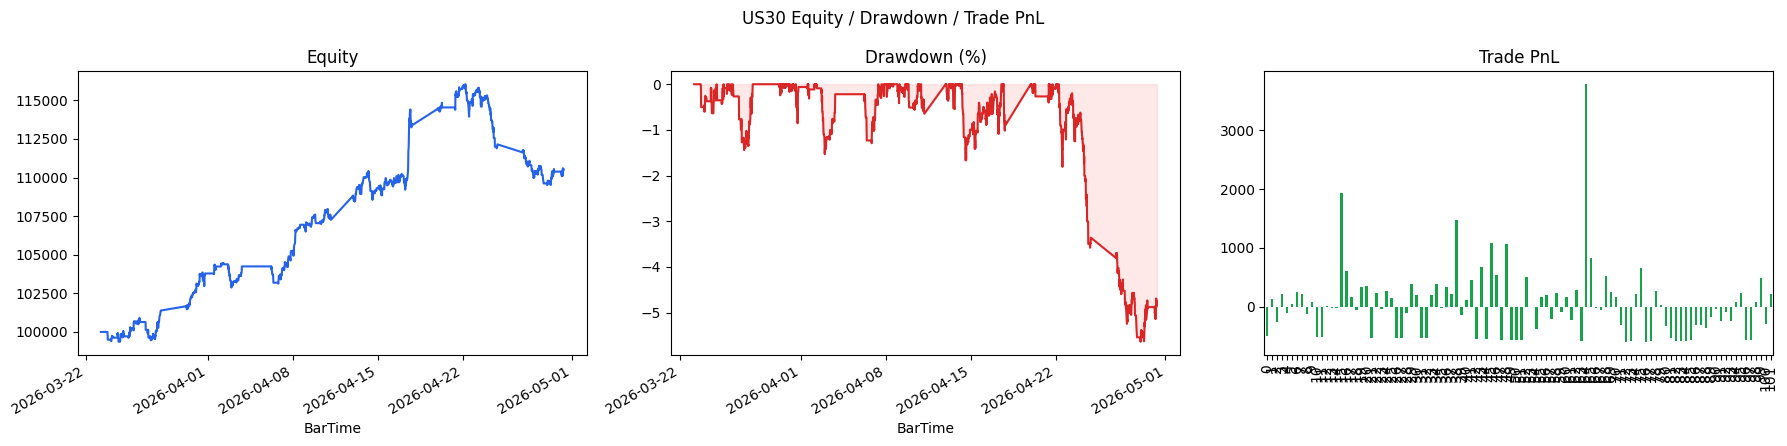

symbol,entry_time,exit_time,direction,entry,exit,lot_size,pnl_usd,r_multiple,exit_reason,partial_tp_hit,commission,swap_cost
US30,2026-04-23 11:00:00+00:00,2026-04-23 12:00:00+00:00,-1,49183.171341,49298.444965,4.810000,-588.140000,-1.022500,SL,False,33.670000,0.000000
US30,2026-04-23 13:40:00+00:00,2026-04-23 17:00:00+00:00,1,49303.438171,49320.001696,3.630000,273.340000,0.110000,SL,True,25.410000,-0.000000
US30,2026-04-23 18:20:00+00:00,2026-04-23 23:20:00+00:00,-1,49281.040710,49261.239408,2.380000,30.470000,0.084700,REVERSED,False,16.660000,0.000000
US30,2026-04-23 23:20:00+00:00,2026-04-24 03:20:00+00:00,1,49261.239408,49173.773485,3.540000,-322.020000,-0.562900,REVERSED,False,24.780000,-12.390000
US30,2026-04-24 03:20:00+00:00,2026-04-24 07:20:00+00:00,-1,49173.773485,49271.021381,5.150000,-536.880000,-0.932200,REVERSED,False,36.050000,0.000000
US30,2026-04-24 07:20:00+00:00,2026-04-24 08:00:00+00:00,1,49271.021381,49184.279144,6.260000,-586.830000,-1.030000,SL,False,43.820000,-0.000000
US30,2026-04-24 09:40:00+00:00,2026-04-24 11:00:00+00:00,-1,49161.374633,49263.665566,5.320000,-581.430000,-1.025300,SL,False,37.240000,0.000000
US30,2026-04-24 12:40:00+00:00,2026-04-24 13:20:00+00:00,1,49263.935117,49123.100530,3.890000,-575.080000,-1.018400,SL,False,27.230000,-0.000000
US30,2026-04-24 15:20:00+00:00,2026-04-24 15:40:00+00:00,-1,49124.859172,49287.824074,3.360000,-571.080000,-1.015900,SL,False,23.520000,0.000000
US30,2026-04-24 19:00:00+00:00,2026-04-26 23:20:00+00:00,1,49200.535435,49119.568738,3.820000,-309.290000,-0.580600,REVERSED,False,26.740000,-26.740000


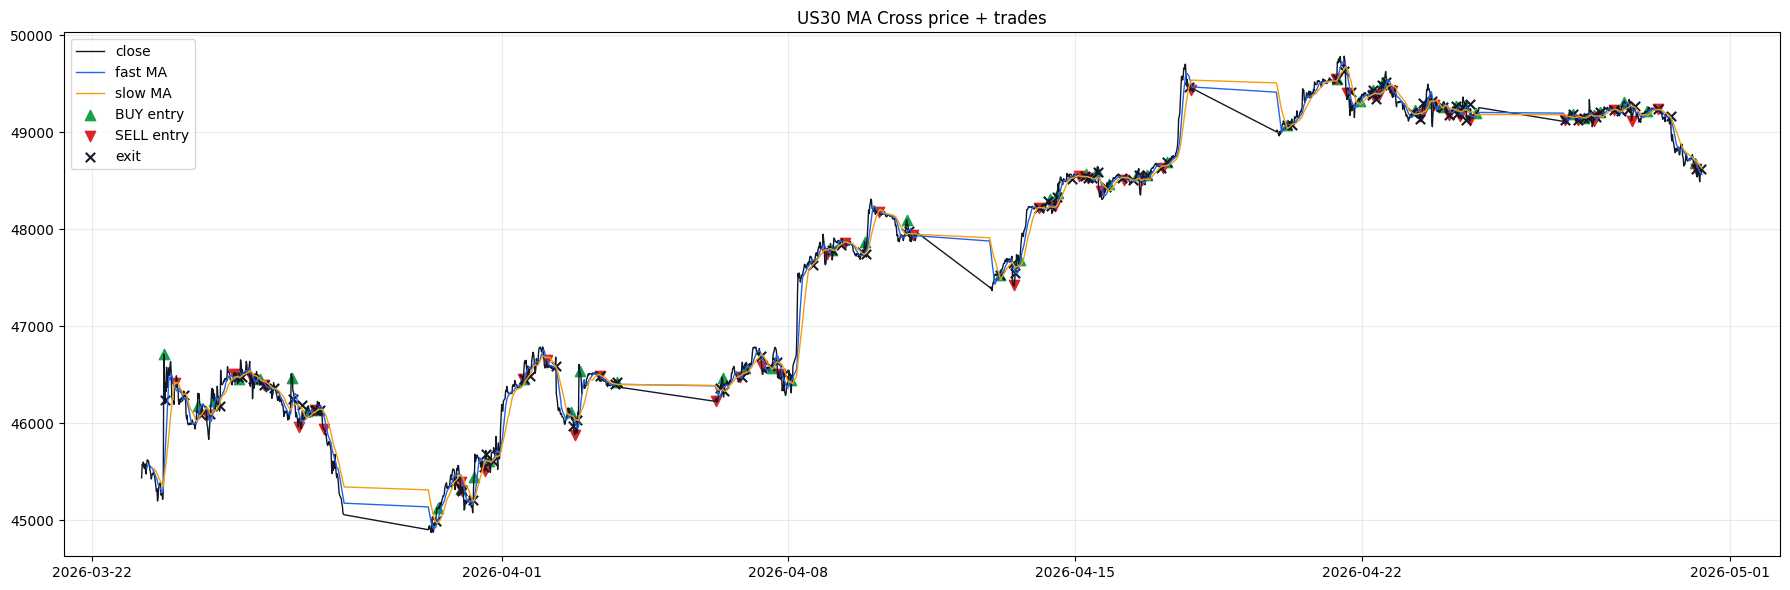

,symbol,entry_time,exit_time,direction,entry,exit,lot_size,pnl_usd,r_multiple,exit_reason,partial_tp_hit,commission,swap_cost
77,US30,2026-04-23 11:00:00+00:00,2026-04-23 12:00:00+00:00,-1,"49,183.1713","49,298.4450",4.8100,-588.1400,-1.0225,SL,False,33.6700,0.0000
78,US30,2026-04-23 13:40:00+00:00,2026-04-23 17:00:00+00:00,1,"49,303.4382","49,320.0017",3.6300,273.3400,0.1100,SL,True,25.4100,-0.0000
79,US30,2026-04-23 18:20:00+00:00,2026-04-23 23:20:00+00:00,-1,"49,281.0407","49,261.2394",2.3800,30.4700,0.0847,REVERSED,False,16.6600,0.0000
80,US30,2026-04-23 23:20:00+00:00,2026-04-24 03:20:00+00:00,1,"49,261.2394","49,173.7735",3.5400,-322.0200,-0.5629,REVERSED,False,24.7800,-12.3900
81,US30,2026-04-24 03:20:00+00:00,2026-04-24 07:20:00+00:00,-1,"49,173.7735","49,271.0214",5.1500,-536.8800,-0.9322,REVERSED,False,36.0500,0.0000
82,US30,2026-04-24 07:20:00+00:00,2026-04-24 08:00:00+00:00,1,"49,271.0214","49,184.2791",6.2600,-586.8300,-1.0300,SL,False,43.8200,-0.0000
83,US30,2026-04-24 09:40:00+00:00,2026-04-24 11:00:00+00:00,-1,"49,161.3746","49,263.6656",5.3200,-581.4300,-1.0253,SL,False,37.2400,0.0000
84,US30,2026-04-24 12:40:00+00:00,2026-04-24 13:20:00+00:00,1,"49,263.9351","49,123.1005",3.8900,-575.0800,-1.0184,SL,False,27.2300,-0.0000
85,US30,2026-04-24 15:20:00+00:00,2026-04-24 15:40:00+00:00,-1,"49,124.8592","49,287.8241",3.3600,-571.0800,-1.0159,SL,False,23.5200,0.0000
86,US30,2026-04-24 19:00:00+00:00,2026-04-26 23:20:00+00:00,1,"49,200.5354","49,119.5687",3.8200,-309.2900,-0.5806,REVERSED,False,26.7400,-26.7400


In [5]:
# Cell 5 - Timeframe matrix baseline

matrix_config = {k: v for k, v in RUN_CONFIG.items() if k not in {'tf', 'replay', 'export_ctrader', 'collect_events'}}
matrix, results = run_timeframe_matrix(**matrix_config)
show_note('Timeframe Matrix', 'Rows compare the same symbol and configuration across available MA Cross timeframes.')
display(matrix)

best_tf = matrix.sort_values(['sharpe', 'profit_factor'], ascending=False).iloc[0]['timeframe'] if not matrix.empty else RUN_CONFIG['tf']
result = results[best_tf]
RUN_CONFIG['tf'] = best_tf
print('Selected timeframe for inspection:', best_tf)
render_symbol_backtest_report(result, RUN_CONFIG)


In [6]:
# Cell 6 - Interactive replay chart dashboard

symbol_replay_dashboard = build_symbol_replay_backtest_widget(
    symbols=SYMBOLS,
    run_symbol_backtest=run_symbol_backtest,
    default_config=RUN_CONFIG,
    global_ns=globals(),
)
display(symbol_replay_dashboard)


In [8]:
# Cell 7 - Optional cTrader validation export

if 'result' not in globals():
    print('No result yet. Run Cell 5 or the interactive dashboard first.')
elif RUN_CONFIG.get('export_ctrader'):
    out = export_ctrader_validation_bundle(
        result,
        RUN_CONFIG,
        name=f"{result.symbol}_{RUN_CONFIG['account_mode']}_{RUN_CONFIG['tf']}_symbol_backtest",
    )
    print('cTrader validation export:', out)
else:
    print("cTrader export is disabled. Set RUN_CONFIG['export_ctrader'] = True to save validation CSV files.")


cTrader export is disabled. Set RUN_CONFIG['export_ctrader'] = True to save validation CSV files.
